In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

A 3D point: $p = (2, 3, 1)$

Your Tasks:

1. Rotate **30°** around the **Y-axis**
2. Rotate **45°** around the **X-axis**
3. Rotate **60°** around the **Z-axis**
4. Combine all three rotations

### 3D Rotation Matrices

| Axis | Matrix |
|------|--------|
| **X-axis** | $\begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{bmatrix}$ |
| **Y-axis** | $\begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$ |
| **Z-axis** | $\begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$ |

rotations **(Y, X, Z)** are called **Euler angles** — widely used in:

- **3D games** — character rotation
- **Aircraft** — yaw, pitch, roll
- **Robotics** — joint movements

In [21]:
p = np.array([2, 3, 1])

def rotation_3d_matrix(axis, theta):
    c, s = np.cos(theta), np.sin(theta)
    
    if axis == 'x':
        return np.array([
            [1, 0, 0],
            [0, c, -s],
            [0, s, c]
        ])
    elif axis == 'y':
        return np.array([
            [c, 0, s],
            [0, 1, 0],
            [-s, 0, c]
        ])
    elif axis == 'z':
        return np.array([
            [c, -s, 0],
            [s, c, 0],
            [0, 0, 1]
        ])

R_y = rotation_3d_matrix('y', np.deg2rad(30))
R_x = rotation_3d_matrix('x', np.deg2rad(45))
R_z = rotation_3d_matrix('z', np.deg2rad(60))

R_combined = R_z @ R_x @ R_y
R_combined @ p

array([-0.80313425,  3.04104005,  2.026586  ])

In [22]:
# another way
p = np.array([2, 3, 1])

r_y = Rotation.from_euler('y', 30, degrees=True)
r_x = Rotation.from_euler('x', 45, degrees=True)
r_z = Rotation.from_euler('z', 60, degrees=True)

r_combined = r_z * r_x * r_y
r_combined.apply(p)

array([-0.80313425,  3.04104005,  2.026586  ])

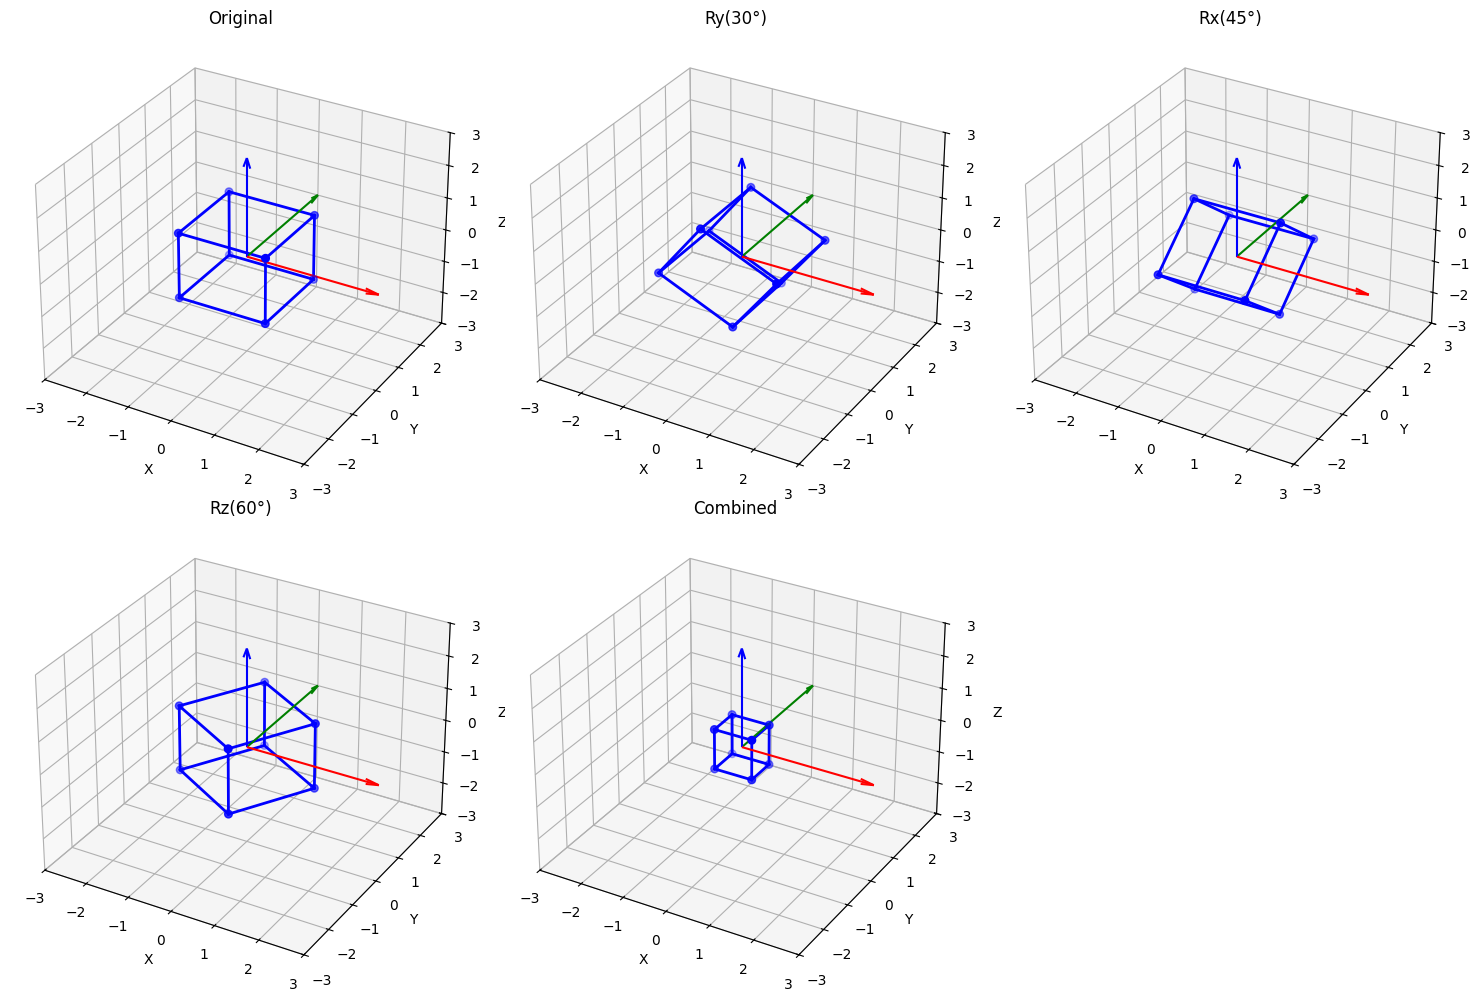

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_cube(size=1):
    s = size / 2
    vertices = np.array([
        [-s, -s, -s],
        [ s, -s, -s],
        [ s,  s, -s],
        [-s,  s, -s],
        [-s, -s,  s],
        [ s, -s,  s],
        [ s,  s,  s],
        [-s,  s,  s]
    ])
    
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    
    return vertices, edges

fig = plt.figure(figsize=(15, 10))

rotations = [
    ('Original', np.eye(3)),
    ('Ry(30°)', R_y),
    ('Rx(45°)', R_x),
    ('Rz(60°)', R_z),
    ('Combined', R_z * R_x * R_y)
]

for i, (title, R) in enumerate(rotations):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    
    vertices, edges = create_cube(2)
    transformed = vertices @ R.T
    
    ax.scatter(transformed[:, 0], transformed[:, 1], transformed[:, 2], 
               color='blue', s=30)
    
    for edge in edges:
        ax.plot3D(transformed[edge, 0], transformed[edge, 1], transformed[edge, 2], 'b-', linewidth=2)
    
    ax.quiver(0, 0, 0, 3, 0, 0, color='r', arrow_length_ratio=0.1)
    ax.quiver(0, 0, 0, 0, 3, 0, color='g', arrow_length_ratio=0.1)
    ax.quiver(0, 0, 0, 0, 0, 3, color='b', arrow_length_ratio=0.1)
    
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.savefig('021_3d_transformation.png', dpi=70)
plt.show()